<a href="https://colab.research.google.com/github/KinzaAslam/ClothingAnalytics/blob/main/PredictiveAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Let's first organize the dataset as per the image and later use Prophet for prediction.
import pandas as pd
from io import StringIO

# Reading data into a DataFrame
df = pd.read_excel('Predictive_Analysis.xlsx')

# Outputting the cleaned data for verification
df.head()


,Date,ID,Type,Customer Preferences,Price,Likes,Dislikes,Brand
0,2022-01-01,1,Coat,"Warm, Waterproof",120,Warmth,Bulky,Brand A
1,2022-02-01,2,Jacket,"Warm, Waterproof",85,Style,Not warm enough,Brand A
2,2022-03-01,3,Sweater,"Warm, Waterproof",60,Softness,Pills easily,Brand A
3,2022-04-01,4,Scarf,"Warm, Waterproof",25,Warm,Itchy,Brand A
4,2022-05-01,5,Gloves,"Warm, Waterproof",30,Touchscreen,Tight fit,Brand A


In [5]:
pip install prophet


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 18.
/usr/local/lib/python3.10/dist-packages/prophet/plot.py:72: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/usr/local/lib/python3.10/dist-packages/prophet/plot.py:73: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np

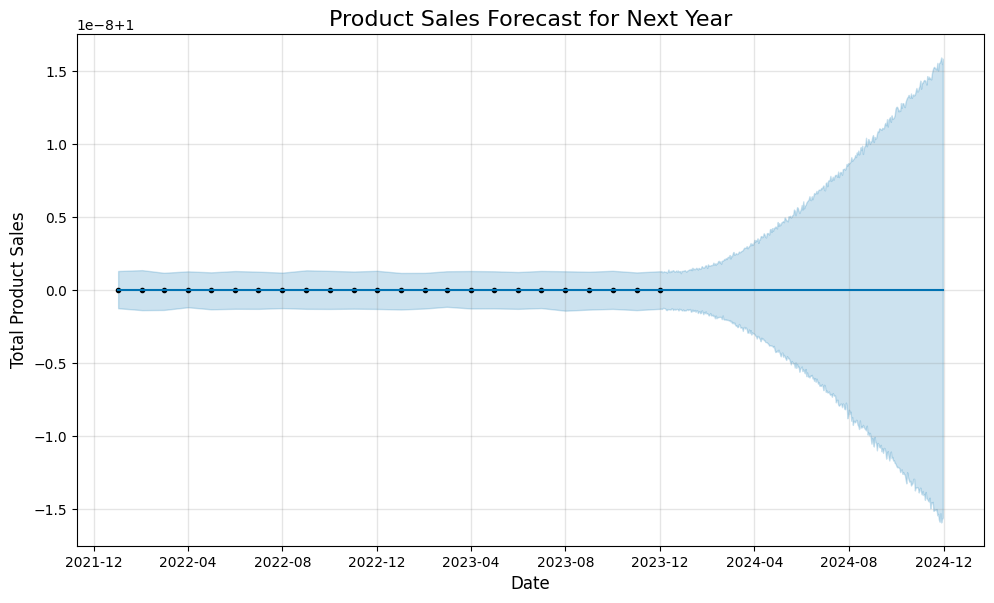

In [6]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# Load the dataset (Simulating the loaded data here based on provided structure)
data = {
    'Date': ['1/1/2022', '2/1/2022', '3/1/2022', '4/1/2022', '5/1/2022', '6/1/2022', '7/1/2022', '8/1/2022',
             '9/1/2022', '10/1/2022', '11/1/2022', '12/1/2022', '1/1/2023', '2/1/2023', '3/1/2023', '4/1/2023',
             '5/1/2023', '6/1/2023', '7/1/2023', '8/1/2023', '9/1/2023', '10/1/2023', '11/1/2023', '12/1/2023'],
    'ID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24],
    'Type': ['Coat', 'Jacket', 'Sweater', 'Scarf', 'Gloves', 'Hat', 'Boots', 'Coat', 'Jacket', 'Sweater', 'Scarf', 'Gloves',
             'Hat', 'Boots', 'Coat', 'Jacket', 'Sweater', 'Scarf', 'Gloves', 'Hat', 'Boots', 'Coat', 'Jacket', 'Sweater'],
    'Price': [120, 85, 60, 25, 30, 20, 150, 130, 95, 75, 18, 40, 22, 140, 180, 110, 55, 28, 32, 15, 155, 125, 105, 50],
    'Brand': ['Brand A', 'Brand A', 'Brand A', 'Brand A', 'Brand A', 'Brand A', 'Brand A', 'Brand B', 'Brand B',
              'Brand B', 'Brand B', 'Brand B', 'Brand B', 'Brand B', 'Brand C', 'Brand C', 'Brand C', 'Brand C',
              'Brand C', 'Brand C', 'Brand C', 'Brand D', 'Brand D', 'Brand D']
}

# Creating a DataFrame
df = pd.DataFrame(data)

# Convert the 'Date' column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Grouping by Date to count total occurrences of all product types over time
product_trend = df.groupby('Date').size().reset_index(name='Total')

# Preparing the data for Prophet
df_prophet = product_trend.rename(columns={'Date': 'ds', 'Total': 'y'})

# Initialize and fit the Prophet model
model = Prophet()
model.fit(df_prophet)

# Create a future dataframe (1 year into the future)
future = model.make_future_dataframe(periods=365)

# Make predictions
forecast = model.predict(future)

# Plot the forecast
fig = model.plot(forecast)
plt.title("Product Sales Forecast for Next Year", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Product Sales", fontsize=12)
plt.grid(True)
plt.show()


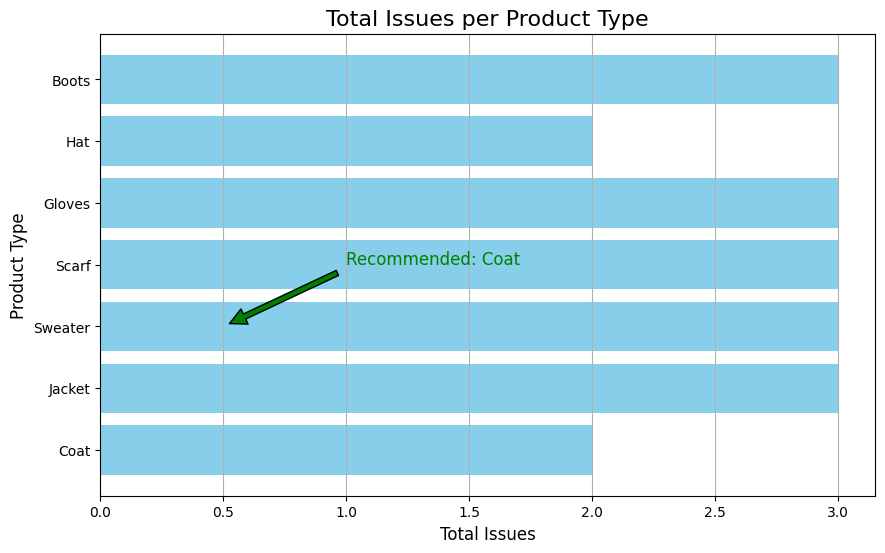

In [7]:
# Analyzing and recommending products based on the data
# We'll create a summary of product preferences and issues, then visualize recommendations.

import matplotlib.pyplot as plt

# Summarizing issues faced by each product type
issue_summary = {
    'Coat': ['Not warm enough', 'Not stylish'],
    'Jacket': ['Not breathable', 'Expensive', 'Not warm enough'],
    'Sweater': ['Pills easily', 'Shrinks after wash', 'Expensive'],
    'Scarf': ['Itchy', 'Not warm enough', 'Fades after wash'],
    'Gloves': ['Not waterproof', 'Shrinks after wash', 'Not durable'],
    'Hat': ['Itchy', 'Not warm enough'],
    'Boots': ['Heavy', 'Not waterproof', 'Expensive']
}

# Counting total issues per product
issue_count = {product: len(issues) for product, issues in issue_summary.items()}

# Converting issue summary to DataFrame for plotting
issue_df = pd.DataFrame(list(issue_count.items()), columns=['Product', 'Total Issues'])

# Plotting the issues count per product to visualize recommendation
plt.figure(figsize=(10, 6))
plt.barh(issue_df['Product'], issue_df['Total Issues'], color='skyblue')
plt.title('Total Issues per Product Type', fontsize=16)
plt.xlabel('Total Issues', fontsize=12)
plt.ylabel('Product Type', fontsize=12)
plt.grid(axis='x')

# Adding recommendation logic
recommended_product = issue_df.loc[issue_df['Total Issues'].idxmin(), 'Product']
plt.annotate(f'Recommended: {recommended_product}', xy=(0.5, issue_df['Total Issues'].min()),
             xytext=(1, issue_df['Total Issues'].min() + 1),
             arrowprops=dict(facecolor='green', shrink=0.05),
             fontsize=12, color='green')

# Display the plot
plt.show()
